# Visualização de máscaras por região

Gera figuras para relatório/dissertação: imagem original + overlay de cada configuração de máscara.

Reutiliza `models/face_detector.py` e `models/masks.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = Path("/mnt/study-data/dcarvalho/datasets/celebahq_pp")
OUTPUT_DIR = Path("/mnt/study-data/dcarvalho/tests/new_masks_view")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 224
NUM_SAMPLES = 6
CTX_ID = -1

# Colunas do grid (label, tipo, spec de regiões)
# tipo: "fixed" usa elipse centrada; "landmarks" usa models/masks.py
MASK_COLUMNS = [
    ("fixed-full", "fixed", "full"),
    ("landmarks-full", "landmarks", "full"),
    ("eyes", "landmarks", "eyes"),
    ("eyes+nose", "landmarks", "eyes,nose"),
    ("nose+mouth", "landmarks", "nose,mouth"),
    ("eyes+nose+mouth", "landmarks", "eyes,nose,mouth"),
]

print(f"Project root: {ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /home/dcarvalho/Lightweight-Face-De-identification
Output dir: /mnt/study-data/dcarvalho/tests/new_masks_view


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from models.face_detector import FaceDetector, _to_bgr_uint8
from models.masks import build_region_mask, parse_mask_regions
from models.transformer import build_elliptic_face_mask

device = torch.device("cpu")
detector = FaceDetector(ctx_id=CTX_ID)
fixed_mask = build_elliptic_face_mask(IMAGE_SIZE, IMAGE_SIZE, device)


def load_rgb(path: Path) -> np.ndarray:
    bgr = _to_bgr_uint8(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def mask_tensor_to_numpy(mask: torch.Tensor) -> np.ndarray:
    return mask.squeeze().detach().cpu().numpy()


def overlay_mask(rgb: np.ndarray, mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    """Sobrepõe máscara (0-1) em verde sobre a imagem."""
    out = rgb.astype(np.float32).copy()
    tint = np.zeros_like(out)
    tint[..., 1] = 255.0 * mask
    m = mask[..., None]
    out = out * (1.0 - alpha * m) + tint * (alpha * m)
    return out.clip(0, 255).astype(np.uint8)


def get_mask_for_column(
    landmarks: np.ndarray | None,
    mask_type: str,
    regions_spec: str,
) -> np.ndarray:
    if mask_type == "fixed":
        return mask_tensor_to_numpy(fixed_mask)
    if landmarks is None:
        return mask_tensor_to_numpy(fixed_mask)
    regions = parse_mask_regions(regions_spec)
    mask = build_region_mask(landmarks, regions, IMAGE_SIZE, IMAGE_SIZE, device)
    return mask_tensor_to_numpy(mask)

/home/dcarvalho/Lightweight-Face-De-identification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dcarvalho/Lightweight-Face-De-identification/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/dcarvalho/.insightface/models/buffalo_m/det_2.5g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/dcarvalho/.insightface/models/buffalo_m/w600k_r50.onnx recognition
set det-size: [(128, 128), (640, 640)]


In [3]:
input_files = sorted(DATA_DIR.glob("*.jpg"))[:NUM_SAMPLES]
if len(input_files) < 1:
    raise RuntimeError(f"Nenhuma imagem em {DATA_DIR}")

print(f"Gerando figuras para {len(input_files)} imagens...")

Gerando figuras para 6 imagens...


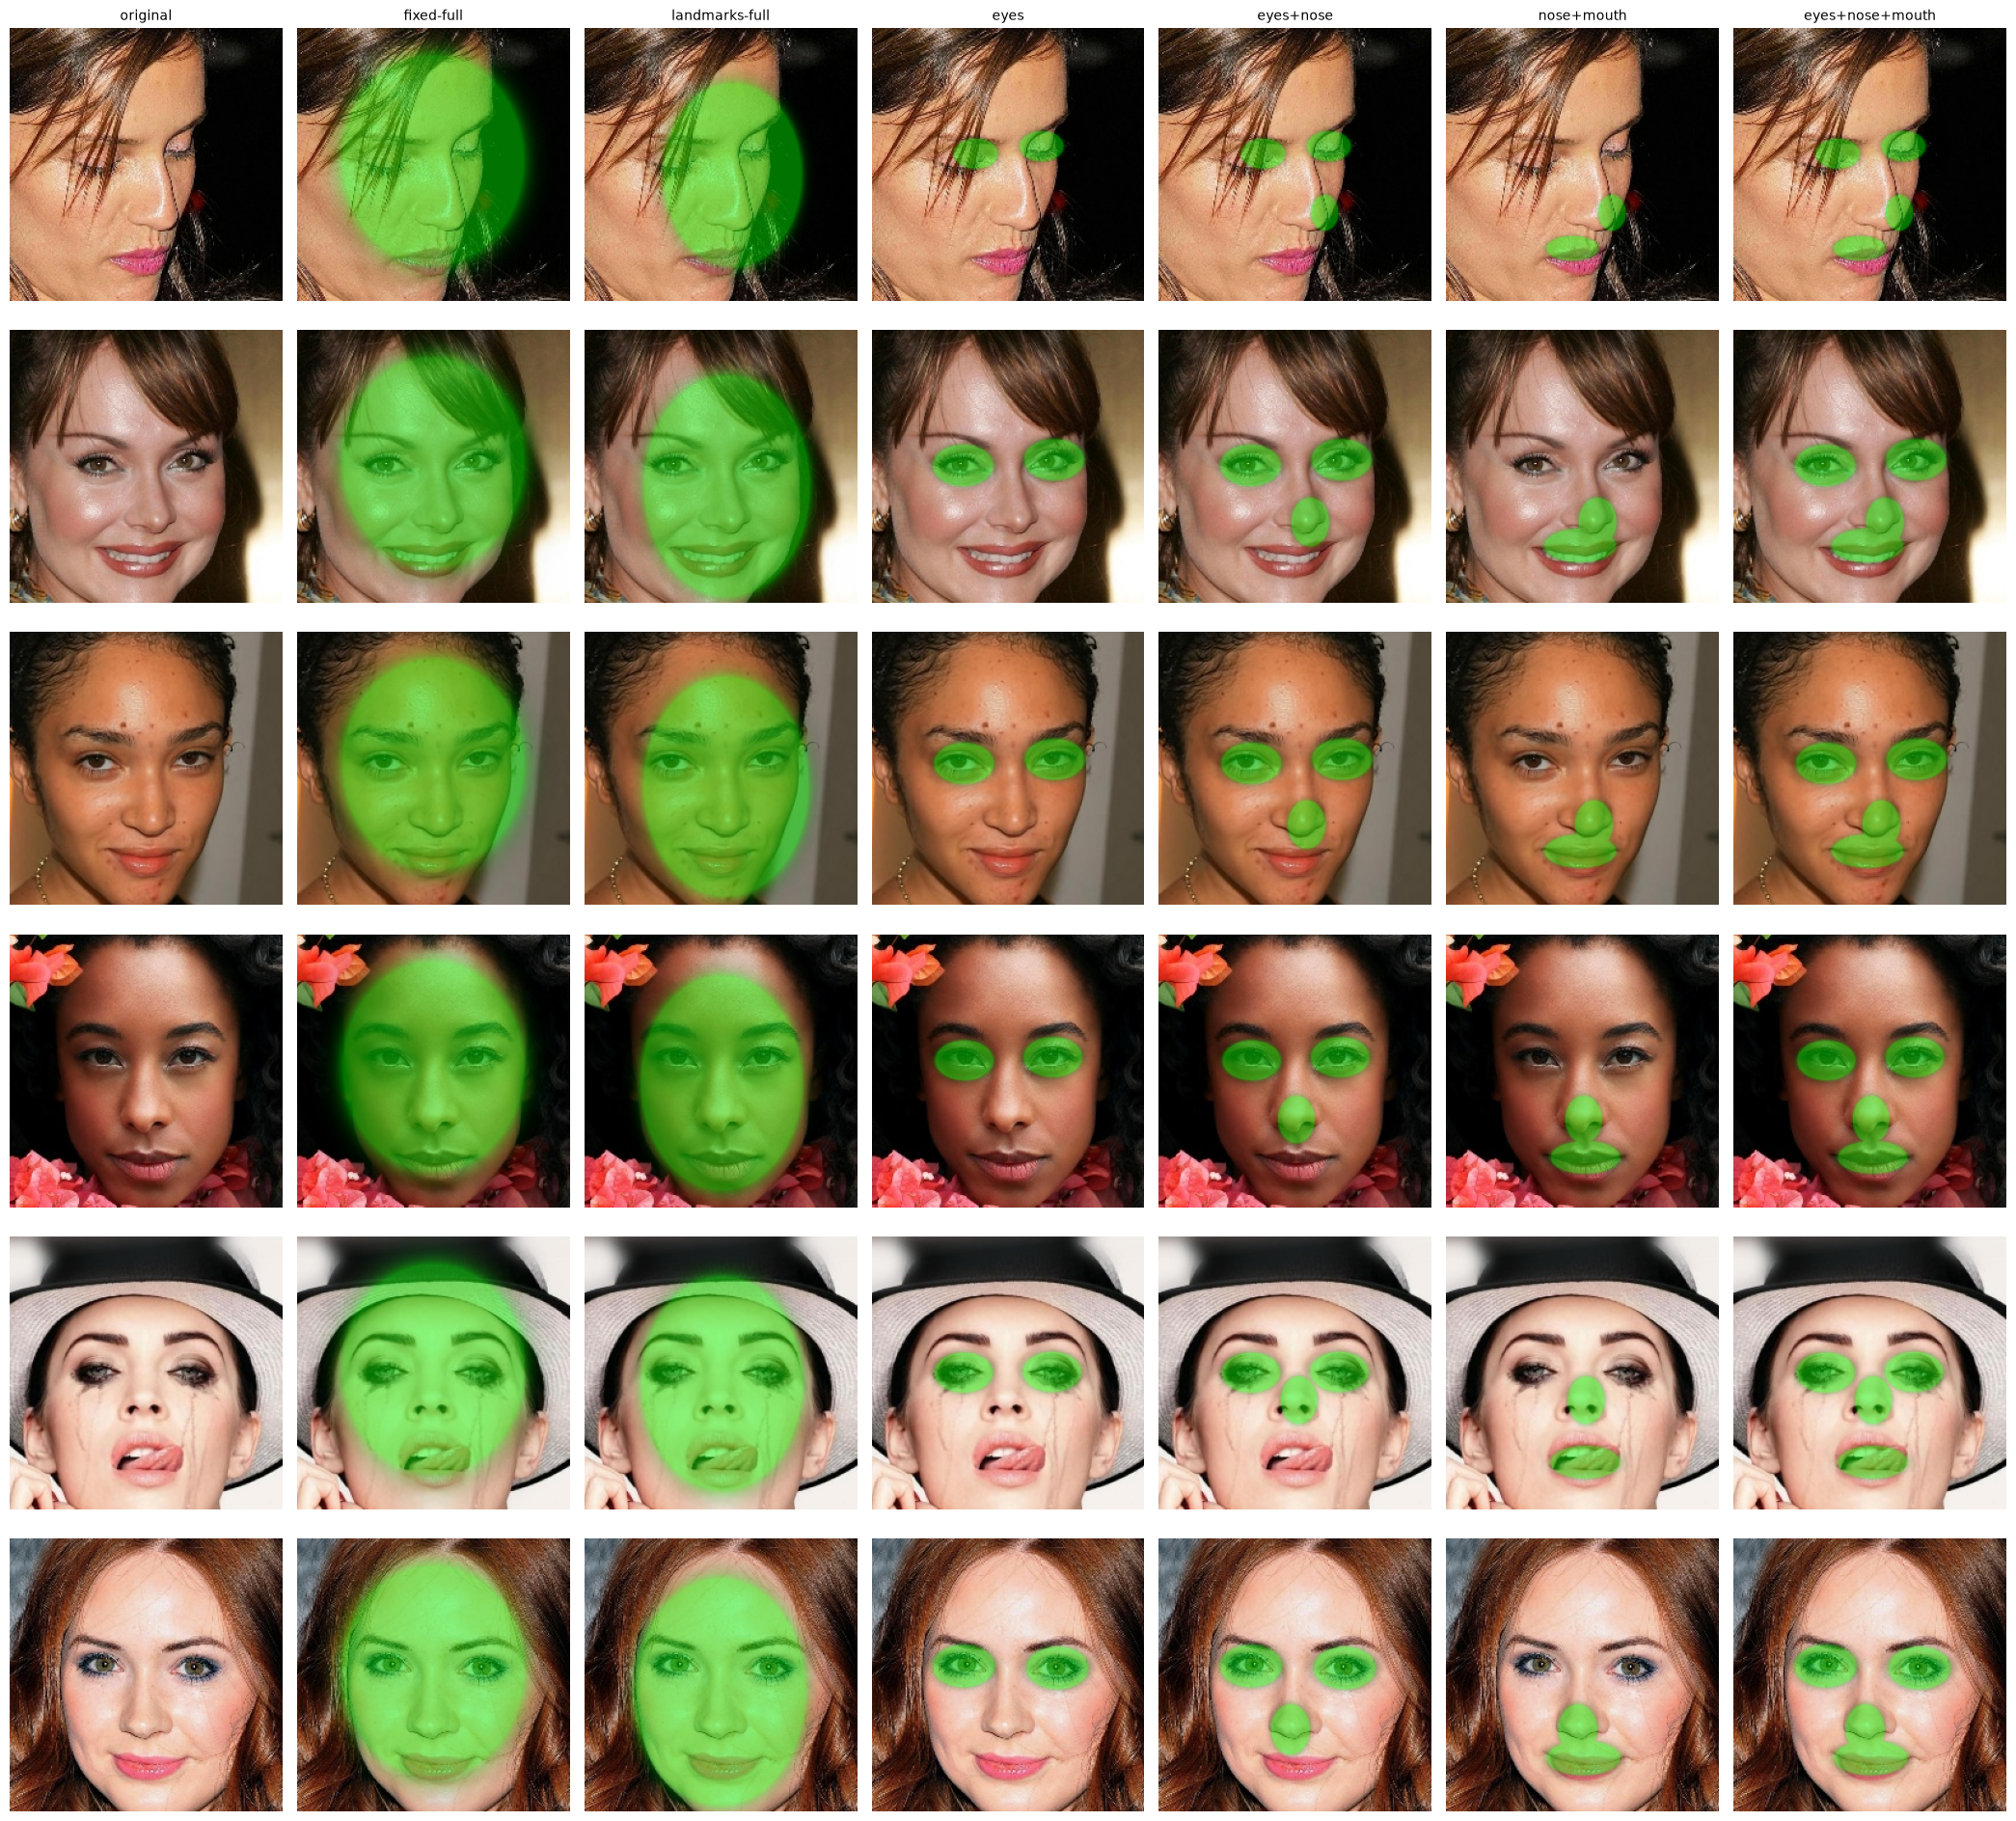

Grid salvo: /mnt/study-data/dcarvalho/tests/new_masks_view/mask_regions_grid.jpg


In [4]:
n_cols = 1 + len(MASK_COLUMNS)
fig_h = 3.2 * len(input_files)
fig_w = 3.0 * n_cols

fig, axes = plt.subplots(len(input_files), n_cols, figsize=(fig_w, fig_h))
if len(input_files) == 1:
    axes = np.expand_dims(axes, axis=0)

col_titles = ["original"] + [label for label, _, _ in MASK_COLUMNS]

for row, img_path in enumerate(input_files):
    rgb = load_rgb(img_path)
    detection = detector.detect_best(img_path)
    landmarks = detection.landmarks if detection is not None else None

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_ylabel(img_path.stem, fontsize=9)
    axes[row, 0].axis("off")

    for col, (label, mask_type, regions_spec) in enumerate(MASK_COLUMNS, start=1):
        mask = get_mask_for_column(landmarks, mask_type, regions_spec)
        overlay = overlay_mask(rgb, mask)
        axes[row, col].imshow(overlay)
        axes[row, col].axis("off")

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

plt.tight_layout()
grid_path = OUTPUT_DIR / "mask_regions_grid.jpg"
fig.savefig(grid_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Grid salvo: {grid_path}")

In [5]:
# Figuras individuais por imagem (útil para slides)
for img_path in input_files:
    rgb = load_rgb(img_path)
    detection = detector.detect_best(img_path)
    landmarks = detection.landmarks if detection is not None else None

    fig, axes = plt.subplots(1, n_cols, figsize=(fig_w, 3.2))
    axes[0].imshow(rgb)
    axes[0].set_title("original")
    axes[0].axis("off")

    for col, (label, mask_type, regions_spec) in enumerate(MASK_COLUMNS, start=1):
        mask = get_mask_for_column(landmarks, mask_type, regions_spec)
        axes[col].imshow(overlay_mask(rgb, mask))
        axes[col].set_title(label)
        axes[col].axis("off")

    plt.tight_layout()
    out_path = OUTPUT_DIR / f"{img_path.stem}_masks.jpg"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Salvo: {out_path}")

Salvo: /mnt/study-data/dcarvalho/tests/new_masks_view/img_00000_masks.jpg
Salvo: /mnt/study-data/dcarvalho/tests/new_masks_view/img_00001_masks.jpg
Salvo: /mnt/study-data/dcarvalho/tests/new_masks_view/img_00002_masks.jpg
Salvo: /mnt/study-data/dcarvalho/tests/new_masks_view/img_00003_masks.jpg
Salvo: /mnt/study-data/dcarvalho/tests/new_masks_view/img_00004_masks.jpg
Salvo: /mnt/study-data/dcarvalho/tests/new_masks_view/img_00005_masks.jpg


In [6]:
print(f"\nFiguras disponíveis em: {OUTPUT_DIR}")


Figuras disponíveis em: /mnt/study-data/dcarvalho/tests/new_masks_view
